In [1]:
###Step 1: Import Libraries
!pip install yfinance numpy pandas matplotlib

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
##Step 2: Download Stock Data

#get real world stock prices so we can calculate the rsi and build our strategy
data = yf.download('NVDA', start='2022-01-01',end='2023-01-01')
data.head()


/tmp/ipython-input-2212501964.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('NVDA', start='2022-01-01',end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2022-01-03,30.062769,30.651628,29.727418,29.757361,391547000
2022-01-04,29.233370,30.409092,28.294189,30.218461,527154000
2022-01-05,27.550631,29.359128,27.479769,28.893029,498064000
2022-01-06,28.123520,28.383017,27.012673,27.586560,454186000
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000


In [25]:
##Step 3: Calculate RSI
#unction to calculate rsi

def calculate_rsi(series, period=14):
  delta = series.diff()
  gain =  (delta.where(delta > 0, 0)).rolling(window=period).mean()
  loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
  rs = gain / loss
  return 100 - (100 / (1 + rs))
data['RSI'] = calculate_rsi(data['Close'])

In [26]:
##Step 4: Create Buy/Sell Signals

data['Signal'] = 0
data.loc[data['RSI'] < 30, 'Signal'] = 1
data.loc[data['RSI'] > 70, 'Signal'] = -1
data['Position'] = data['Signal'].diff()

In [27]:
## Step 5: Calculate Strategy Returns

data['Market Return'] = data['Close'].pct_change()
data['Strategy Return'] = data['Market Return'] * data['Position']

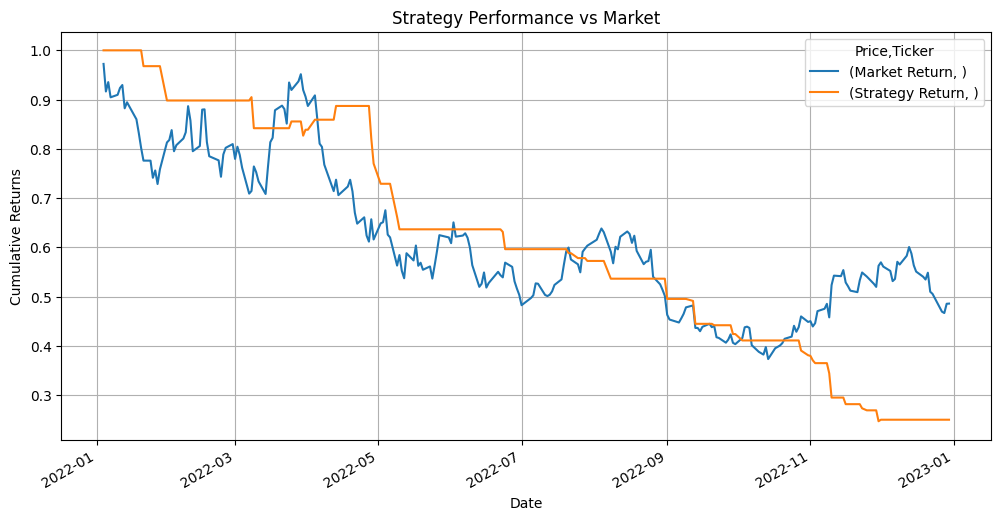

In [28]:
## Step 6: Plot Strategy vs Market

(1 + data[[('Market Return', ''), ('Strategy Return', '')]]).cumprod().plot(figsize=(12,6))
plt.title('Strategy Performance vs Market')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid()
plt.show()

In [8]:
print(data.columns)

MultiIndex([(          'Close', 'AAPL'),
            (           'High', 'AAPL'),
            (            'Low', 'AAPL'),
            (           'Open', 'AAPL'),
            (         'Volume', 'AAPL'),
            (            'RSI',     ''),
            (  'Market Return',     ''),
            (       'Position',     ''),
            ('Strategy Return',     '')],
           names=['Price', 'Ticker'])
